In [1]:
import os
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
load_dotenv()

True

In [2]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class JockState(TypedDict):

    topic : str
    jock : str
    explanation : str

In [5]:
def genrate_jock(state : JockState):
    
    prompt = f'genrate jock on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'jock': response}

In [6]:
def genrate_explanation(state : JockState):

    prompt = f'write an explanation for the jock - {state["jock"]}'
    response =  llm.invoke(prompt).content

    return {'explanation':response}


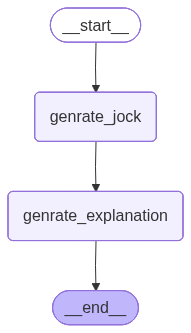

In [7]:
graph = StateGraph(JockState)

graph.add_node('genrate_jock',genrate_jock)
graph.add_node('genrate_explanation',genrate_explanation)

graph.add_edge(START, 'genrate_jock')
graph.add_edge('genrate_jock','genrate_explanation')
graph.add_edge('genrate_explanation',END)

checkpointer = MemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [8]:
config1 = {'configurable': {'thread_id': "1"}}
config2 = {'configurable': {'thread_id': "3"}}

initial_state = {'topic' : 'Pizza'}
final_state = workflow.invoke(initial_state,config=config2)

In [9]:
final_state

{'topic': 'Pizza',
 'jock': 'Here are a few jokes on the topic of pizza:\n\n1. Why was the pizza in a bad mood? Because it was feeling a little crusty!\n2. Why did the pizza go to the doctor? Because it had a saucy attitude!\n3. What did the pizza say when it came out of the oven? "Wow, I\'m hot stuff!"\n4. Why did the pizza delivery guy break up with his girlfriend? Because she was always topping him with complaints!\n5. What do you call a pizza with a bad memory? A pizza that forgets its toppings!\n6. Why did the pizza go to the gym? To get a little more cheese and a lot more dough!\n7. What did the pizza say to the pizza delivery guy? "You\'re the cheese to my macaroni, the pepperoni to my pie!"\n8. Why did the pizza become a detective? Because it was great at delivering clues!\n9. What do you call a pizza that\'s an excellent listener? A pizza that\'s all ears... and crust!\n10. Why did the pizza go to therapy? Because it was struggling to find its topping in life!\n\nHope these jo

In [10]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Pizza', 'jock': 'Here are a few jokes on the topic of pizza:\n\n1. Why was the pizza in a bad mood? Because it was feeling a little crusty!\n2. Why did the pizza go to the doctor? Because it had a saucy attitude!\n3. What did the pizza say when it came out of the oven? "Wow, I\'m hot stuff!"\n4. Why did the pizza delivery guy break up with his girlfriend? Because she was always topping him with complaints!\n5. What do you call a pizza with a bad memory? A pizza that forgets its toppings!\n6. Why did the pizza go to the gym? To get a little more cheese and a lot more dough!\n7. What did the pizza say to the pizza delivery guy? "You\'re the cheese to my macaroni, the pepperoni to my pie!"\n8. Why did the pizza become a detective? Because it was great at delivering clues!\n9. What do you call a pizza that\'s an excellent listener? A pizza that\'s all ears... and crust!\n10. Why did the pizza go to therapy? Because it was struggling to find its topping in l

In [15]:
workflow.get_state(config =config2).values

{'topic': 'Pizza',
 'jock': 'Here are a few jokes on the topic of pizza:\n\n1. Why was the pizza in a bad mood? Because it was feeling a little crusty!\n2. Why did the pizza go to the doctor? Because it had a saucy attitude!\n3. What did the pizza say when it came out of the oven? "Wow, I\'m hot stuff!"\n4. Why did the pizza delivery guy break up with his girlfriend? Because she was always topping him with complaints!\n5. What do you call a pizza with a bad memory? A pizza that forgets its toppings!\n6. Why did the pizza go to the gym? To get a little more cheese and a lot more dough!\n7. What did the pizza say to the pizza delivery guy? "You\'re the cheese to my macaroni, the pepperoni to my pie!"\n8. Why did the pizza become a detective? Because it was great at delivering clues!\n9. What do you call a pizza that\'s an excellent listener? A pizza that\'s all ears... and crust!\n10. Why did the pizza go to therapy? Because it was struggling to find its topping in life!\n\nHope these jo

In [23]:
## wnat to excute the workflow in perticuler checkpoint and again run using checkpoint id
workflow.get_state({'configurable': {'thread_id': "3", 'checkpoint_id': '1f106412-e78f-6a29-8000-f2051541e33b'}})


StateSnapshot(values={'topic': 'Pizza'}, next=('genrate_jock',), config={'configurable': {'thread_id': '3', 'checkpoint_id': '1f106412-e78f-6a29-8000-f2051541e33b'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-02-10T05:27:24.751713+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f106412-e78d-660f-bfff-9c95220fc7bf'}}, tasks=(PregelTask(id='7684d4ae-e272-9b97-b770-9aecfea62e9f', name='genrate_jock', path=('__pregel_pull', 'genrate_jock'), error=None, interrupts=(), state=None, result={'jock': 'Here are a few jokes on the topic of pizza:\n\n1. Why was the pizza in a bad mood? Because it was feeling a little crusty.\n2. Why did the pizza delivery guy break up with his girlfriend? Because she was always topping him with complaints.\n3. What did the pizza say when it came out of the oven? "Wow, I\'m hot stuff!"\n4. Why did the mushroom go to the pizza party? Because he was a fun-gi.\n5. What do you call a pizza w

In [24]:
workflow.invoke(None,{'configurable': {'thread_id': "3", 'checkpoint_id': '1f106412-e78f-6a29-8000-f2051541e33b'}})


{'topic': 'Pizza',
 'jock': 'Here are a few jokes on the topic of pizza:\n\n1. Why was the pizza in a bad mood? Because it was feeling a little crusty!\n2. Why did the pizza go to the doctor? It had a saucy attitude!\n3. What did the pizza say when it came out of the oven? "I\'m hot stuff!"\n4. Why did the pizza delivery guy break up with his girlfriend? Because she was always trying to topping him!\n5. What do you call a pizza with a bad memory? A pizza that\'s a little forgetful of its toppings!\n6. Why did the pizza go to the gym? To get a little more cheesy and flexible!\n7. What did the pizza say when it ran into its ex? "You\'re just a slice of my past!"\n8. Why did the pizza become a musician? Because it was great at delivering hot tracks!\n9. What do you call a pizza that\'s an excellent listener? A pizza that\'s all ears... and crust!\n10. Why did the pizza go to therapy? Because it was struggling to cope with its flaky emotions!\n\nI hope these jokes make you laugh and put a 

In [27]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Pizza', 'jock': 'Here are a few jokes on the topic of pizza:\n\n1. Why was the pizza in a bad mood? Because it was feeling a little crusty!\n2. Why did the pizza go to the doctor? It had a saucy attitude!\n3. What did the pizza say when it came out of the oven? "I\'m hot stuff!"\n4. Why did the pizza delivery guy break up with his girlfriend? Because she was always trying to topping him!\n5. What do you call a pizza with a bad memory? A pizza that\'s a little forgetful of its toppings!\n6. Why did the pizza go to the gym? To get a little more cheesy and flexible!\n7. What did the pizza say when it ran into its ex? "You\'re just a slice of my past!"\n8. Why did the pizza become a musician? Because it was great at delivering hot tracks!\n9. What do you call a pizza that\'s an excellent listener? A pizza that\'s all ears... and crust!\n10. Why did the pizza go to therapy? Because it was struggling to cope with its flaky emotions!\n\nI hope these jokes make

In [28]:
### Updating State

In [30]:
workflow.update_state({'configurable': {'thread_id': "3", 'checkpoint_id': '1f106412-e78f-6a29-8000-f2051541e33b','checkpoint_ns': ''}},{'topic':'samosa'})


{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10645d-db60-6878-8001-8efb12e803d8'}}

In [31]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('genrate_jock',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f10645d-db60-6878-8001-8efb12e803d8'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-02-10T06:00:56.740044+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f106412-e78f-6a29-8000-f2051541e33b'}}, tasks=(PregelTask(id='6de5b0f3-831d-4c5d-1e7e-40710b0abee4', name='genrate_jock', path=('__pregel_pull', 'genrate_jock'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Pizza', 'jock': 'Here are a few jokes on the topic of pizza:\n\n1. Why was the pizza in a bad mood? Because it was feeling a little crusty!\n2. Why did the pizza go to the doctor? It had a saucy attitude!\n3. What did the pizza say when it came out of the oven? "I\'m hot stuff!"\n4. Why did the pizza delivery guy break up with his girlfriend? Becau

In [34]:
workflow.invoke(None,{'configurable': {'thread_id': "3", 'checkpoint_id': '1f10645d-db60-6878-8001-8efb12e803d8'}})


{'topic': 'samosa',
 'jock': 'Here are a few jokes on the topic of samosa:\n\n1. Why did the samosa go to therapy?\nBecause it was feeling a little "crunchy" under the pressure!\n\n2. Why did the samosa join a gym?\nTo get some "flaky" abs!\n\n3. What did the samosa say when it ran into its ex?\n"You\'re just a shell of your former self!"\n\n4. Why did the samosa go on a date?\nBecause it was looking for someone with a "spicy" personality!\n\n5. What do you call a samosa that\'s having an identity crisis?\nA samosa in a "wrap"!\n\n6. Why did the samosa get kicked out of the party?\nBecause it was making too many "corny" jokes!\n\n7. What did the samosa say when it got old?\n"I\'m just a shadow of my former \'pastry\' self!"\n\n8. Why did the samosa go to the doctor?\nIt had a bad case of "filling" anxiety!\n\nI hope you find these jokes "tasty" and enjoyable!',
 'explanation': 'What\'s up bro? So, I know you\'re probably thinking, "Samosa jokes? That\'s a new one." But hear me out. The

In [35]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa', 'jock': 'Here are a few jokes on the topic of samosa:\n\n1. Why did the samosa go to therapy?\nBecause it was feeling a little "crunchy" under the pressure!\n\n2. Why did the samosa join a gym?\nTo get some "flaky" abs!\n\n3. What did the samosa say when it ran into its ex?\n"You\'re just a shell of your former self!"\n\n4. Why did the samosa go on a date?\nBecause it was looking for someone with a "spicy" personality!\n\n5. What do you call a samosa that\'s having an identity crisis?\nA samosa in a "wrap"!\n\n6. Why did the samosa get kicked out of the party?\nBecause it was making too many "corny" jokes!\n\n7. What did the samosa say when it got old?\n"I\'m just a shadow of my former \'pastry\' self!"\n\n8. Why did the samosa go to the doctor?\nIt had a bad case of "filling" anxiety!\n\nI hope you find these jokes "tasty" and enjoyable!', 'explanation': 'What\'s up bro? So, I know you\'re probably thinking, "Samosa jokes? That\'s a new one." 